<a href="https://colab.research.google.com/github/rajuyuvaraj/Handwritten-Digit-Recognizer-using-CNN-MNIST-Dataset-/blob/main/Handwritten%20Digit%20Recognizer%20using%20CNN%20(MNIST%20Dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Handwritten Digit Recognizer using CNN (MNIST Dataset)

This notebook implements a Convolutional Neural Network (CNN) to correctly identify handwritten digits (0–9) from grayscale images using the MNIST dataset.

#### 🔹 Step 1: Import Required Libraries

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

#### 🔹 Step 2: Load MNIST Dataset

In [11]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

#### 🔹 Step 3: Data Preprocessing

- Normalize pixel values (0–255 → 0–1)
- Reshape for CNN input (add a channel dimension for grayscale images)

In [12]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

#### 🔹 Step 4: Build the CNN Model

In [13]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

#### 🔹 Step 5: Compile the Model

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### 🔹 Step 6: Train the Model

In [16]:
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
  30/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 27ms/step - accuracy: 0.9734 - loss: 0.0682

KeyboardInterrupt: 

#### 🔹 Step 7: Evaluate the Model (Optional, but good practice)

In [7]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9886 - loss: 0.0381
Test Loss: 0.0310
Test Accuracy: 0.9907


#### 🔹 Step 8: Visualize Training History (Optional)

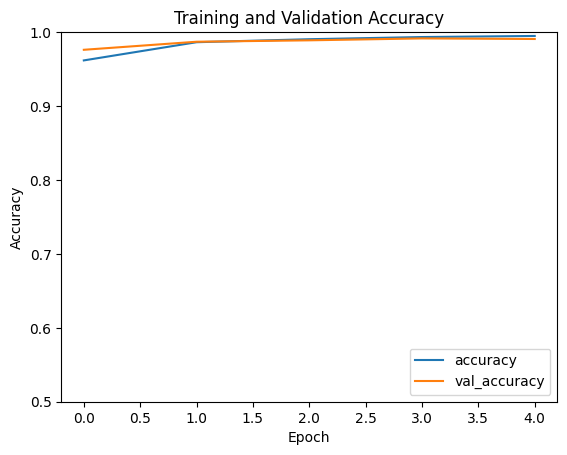

In [8]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

#### 🔹 Step 9: Make Predictions and Visualize Results (Optional)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


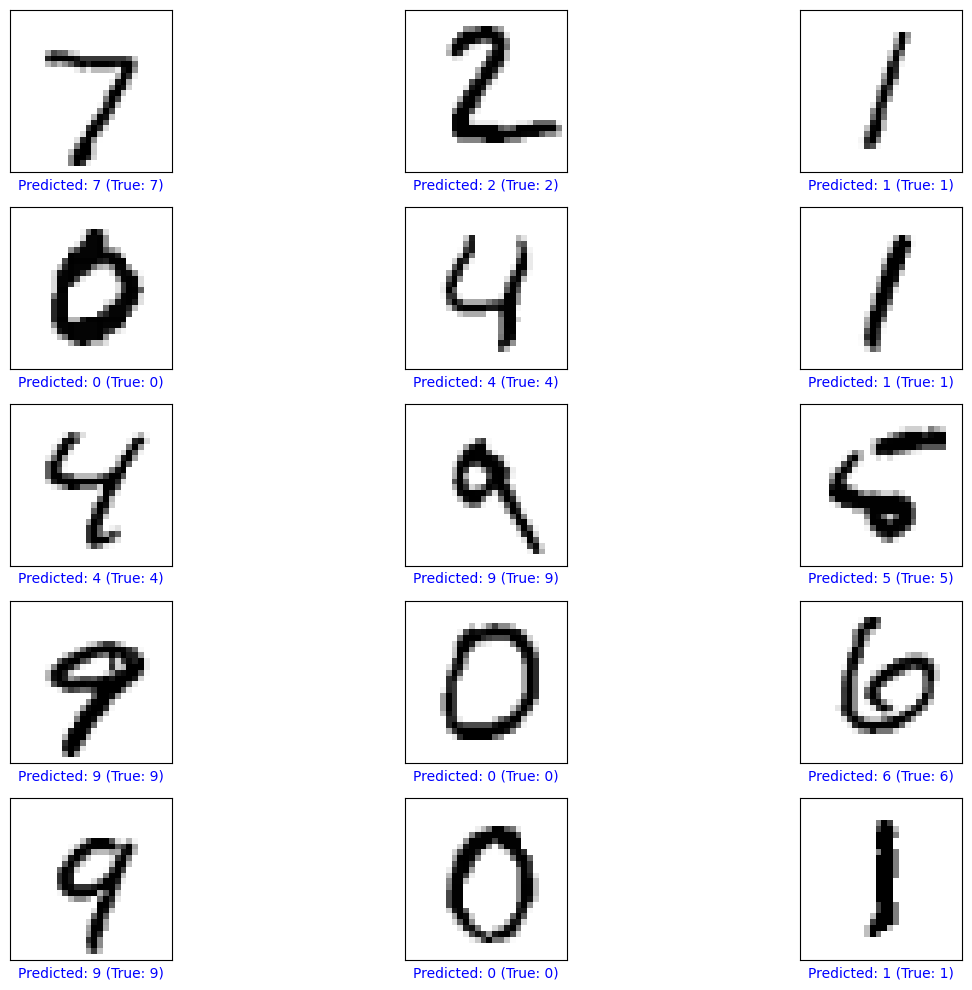

In [9]:
predictions = model.predict(x_test)

def plot_image_prediction(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img.reshape(28, 28), cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel(f"Predicted: {predicted_label} (True: {true_label})", color=color)

num_rows = 5
num_cols = 3
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image_prediction(i, predictions[i], y_test, x_test)
plt.tight_layout()
plt.show()

# Task
Extend the existing digit recognition model to recognize multi-digit numbers from an image. This involves loading a multi-digit image (e.g., "1000.png"), preprocessing it, segmenting individual digits using OpenCV, predicting each digit with the trained CNN model, combining the individual predictions to form the complete number, and visualizing the segmented digits with their predicted labels.

## Load Image for Multi-Digit Recognition

### Subtask:
Load the image containing a multi-digit number (e.g., '1000.png') using OpenCV. Ensure the image file is accessible in the environment. I will prompt you to upload this file if it is not already present.


**Reasoning**:
The subtask requires importing the `cv2` library for image processing. This code block will install `opencv-python` if it's not already installed and then import `cv2`.



In [54]:
try:
    import cv2
    print("OpenCV is already installed.")
except ImportError:
    print("Installing OpenCV...")
    !pip install opencv-python
    import cv2
    print("OpenCV installed and imported successfully.")

OpenCV is already installed.


**Reasoning**:
The next step is to upload the specified image file ('1000.png') using `files.upload()` as instructed.



In [55]:
from google.colab import files

print("Please upload the '1000.png' image file.")
uploaded_multi_digit = files.upload()

image_filename = None
for fn in uploaded_multi_digit.keys():
    image_filename = fn
    print(f'User uploaded file "{fn}"')

if image_filename is None:
    print("No file was uploaded. Please upload '1000.png' to proceed.")

Please upload the '1000.png' image file.


Saving Screenshot 2026-02-02 203912.png to Screenshot 2026-02-02 203912 (3).png
User uploaded file "Screenshot 2026-02-02 203912 (3).png"


**Reasoning**:
The subtask requires loading the image that was just uploaded. Using `cv2.imread()` with the `image_filename` from the previous step will load the image. Specifying `cv2.IMREAD_GRAYSCALE` ensures it's loaded as a single-channel image, consistent with the model's input requirements.



In [56]:
if image_filename:
    multi_digit_image = cv2.imread(image_filename, cv2.IMREAD_GRAYSCALE)
    print(f"Successfully loaded '{image_filename}' with shape: {multi_digit_image.shape}")
else:
    print("No image filename available to load.")

Successfully loaded 'Screenshot 2026-02-02 203912 (3).png' with shape: (67, 170)


**Reasoning**:
The loaded `multi_digit_image` likely has dark digits on a light background, similar to how digits are often presented for MNIST. The pre-trained model was trained on MNIST, which has white digits on a black background. To ensure consistency for optimal prediction, the image needs to be inverted so that digits are white and the background is black. Also, it is good practice to display the image for visual verification.



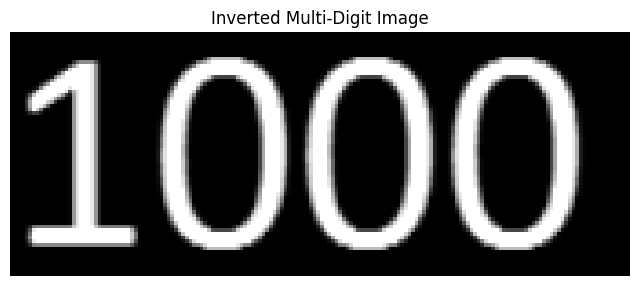

In [57]:
multi_digit_image_inverted = cv2.bitwise_not(multi_digit_image)

plt.figure(figsize=(8, 4))
plt.imshow(multi_digit_image_inverted, cmap='gray')
plt.title('Inverted Multi-Digit Image')
plt.axis('off')
plt.show()

## Preprocess Multi-Digit Image

### Subtask:
Convert the loaded image to grayscale and then apply inverse binary thresholding to prepare it for digit segmentation. This step will make the digits white on a black background, matching the MNIST dataset style.


**Reasoning**:
The subtask requires applying a binary threshold to the inverted image to ensure clean white digits on a black background, which is crucial for subsequent segmentation and consistent with the MNIST dataset style. This step finalizes the image preparation for digit segmentation.



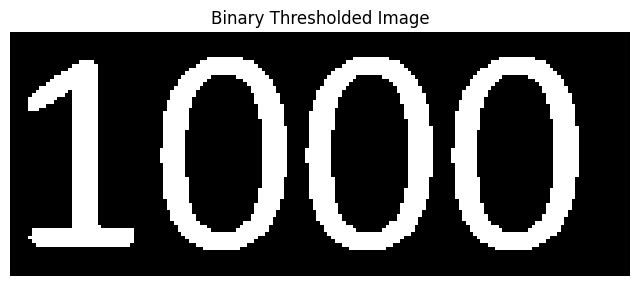

In [58]:
_, thresh_image = cv2.threshold(multi_digit_image_inverted, 127, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(8, 4))
plt.imshow(thresh_image, cmap='gray')
plt.title('Binary Thresholded Image')
plt.axis('off')
plt.show()

## Segment Digits from Image

### Subtask:
Use OpenCV's `findContours` to identify individual digit contours within the preprocessed image. Sort these contours from left to right to ensure correct order of digits.


**Reasoning**:
The subtask requires using `cv2.findContours` to identify individual digit contours within the `thresh_image`. After finding the contours, I need to iterate through them, filter out noise based on size, and store the valid digit bounding boxes. Finally, the extracted digit contours must be sorted from left to right based on their x-coordinate to ensure correct order.



In [59]:
contours, _ = cv2.findContours(thresh_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

digit_bounding_boxes = []

# Define minimum and maximum size for digit contours based on typical digit characteristics
# These values might need adjustment depending on the specific multi-digit image used.
min_contour_area = 50 # Minimum area to consider as a digit
min_contour_width = 10 # Minimum width to consider as a digit
min_contour_height = 10 # Minimum height to consider as a digit

for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    area = cv2.contourArea(contour)

    # Filter contours based on size and aspect ratio to exclude noise and non-digit shapes
    # The aspect ratio check helps ensure the contour is likely a digit (roughly square-ish)
    # These thresholds are heuristic and might need fine-tuning.
    if area > min_contour_area and w > min_contour_width and h > min_contour_height and 0.2 < (w/h) < 2.0:
        digit_bounding_boxes.append((x, y, w, h, contour))

# Sort the identified digits from left to right based on their x-coordinate
digit_bounding_boxes = sorted(digit_bounding_boxes, key=lambda d: d[0])

print(f"Found {len(digit_bounding_boxes)} potential digits.")
print("Sorted bounding boxes (x, y, width, height):")
for i, (x, y, w, h, _) in enumerate(digit_bounding_boxes):
    print(f"Digit {i+1}: x={x}, y={y}, w={w}, h={h}")


Found 4 potential digits.
Sorted bounding boxes (x, y, width, height):
Digit 1: x=5, y=8, w=29, h=51
Digit 2: x=41, y=7, w=35, h=53
Digit 3: x=81, y=7, w=35, h=53
Digit 4: x=121, y=7, w=35, h=53


**Reasoning**:
The subtask of segmenting digits from the image requires extracting each identified digit using its bounding box, resizing it to the model's input dimensions (28x28), and normalizing its pixel values. It is also good practice to visualize these extracted digits to ensure correct segmentation and preprocessing before feeding them to the model.



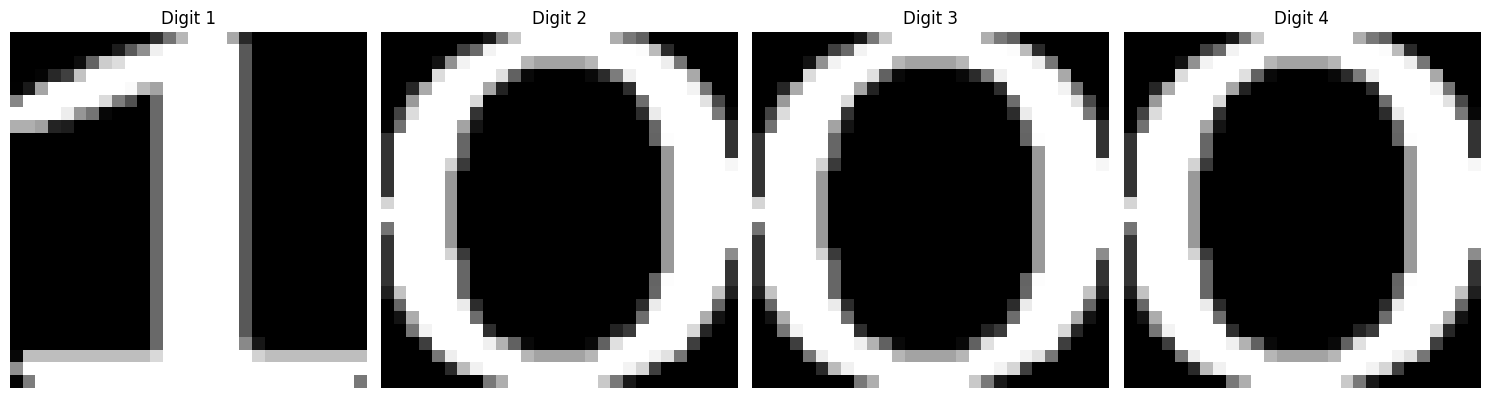

Extracted and preprocessed 4 digits.


In [60]:
extracted_digits = []

plt.figure(figsize=(15, 5))

for i, (x, y, w, h, _) in enumerate(digit_bounding_boxes):
    # Extract the digit using the bounding box from the thresholded image
    digit_roi = thresh_image[y:y+h, x:x+w]

    # Resize the digit to 28x28 pixels, which is the input size for the CNN model
    # Use INTER_AREA for shrinking images, it's generally preferred for pixelated images
    resized_digit = cv2.resize(digit_roi, (28, 28), interpolation=cv2.INTER_AREA)

    # Normalize the pixel values (0-255 to 0-1) and reshape for model input (add channel dimension)
    normalized_digit = resized_digit / 255.0
    model_input_digit = normalized_digit.reshape(1, 28, 28, 1)

    extracted_digits.append(model_input_digit)

    # Visualize the extracted and resized digit
    plt.subplot(1, len(digit_bounding_boxes), i + 1)
    plt.imshow(resized_digit, cmap='gray')
    plt.title(f"Digit {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Extracted and preprocessed {len(extracted_digits)} digits.")

**Reasoning**:
The subtask requires predicting each of the `extracted_digits` using the previously trained `model`. The predictions for each digit should be stored to form the complete multi-digit number.



In [61]:
predicted_digits = []

for i, digit_input in enumerate(extracted_digits):
    # Make prediction for the current digit
    prediction = model.predict(digit_input, verbose=0)
    # Get the predicted label (digit with the highest probability)
    predicted_label = np.argmax(prediction)
    predicted_digits.append(predicted_label)

print(f"Predicted digits: {predicted_digits}")

# Combine individual predictions to form the complete multi-digit number
multi_digit_number = "".join(map(str, predicted_digits))
print(f"Recognized multi-digit number: {multi_digit_number}")

Predicted digits: [np.int64(1), np.int64(0), np.int64(0), np.int64(0)]
Recognized multi-digit number: 1000


**Reasoning**:
The subtask requires visualizing the segmented digits along with their predicted labels to provide a clear understanding of the model's performance on individual digits within the multi-digit image. This step will use `matplotlib.pyplot` to display each `resized_digit` and its corresponding `predicted_label`.



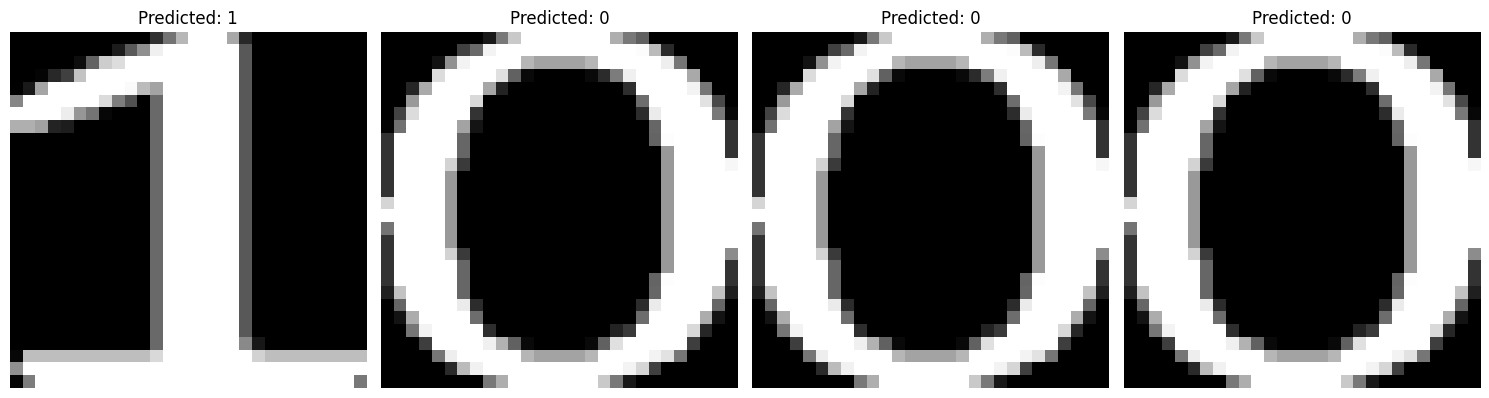

Final recognized multi-digit number: 1000


In [62]:
plt.figure(figsize=(15, 5))

for i, (x, y, w, h, _) in enumerate(digit_bounding_boxes):
    # Extract and resize the digit again for plotting
    digit_roi = thresh_image[y:y+h, x:x+w]
    resized_digit = cv2.resize(digit_roi, (28, 28), interpolation=cv2.INTER_AREA)

    # Display the digit and its prediction
    plt.subplot(1, len(digit_bounding_boxes), i + 1)
    plt.imshow(resized_digit, cmap='gray')
    plt.title(f'Predicted: {predicted_digits[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Final recognized multi-digit number: {multi_digit_number}")